# Step 4：動力学の局所一次近似とQ関数と局所二次近似

## 概要

iLQRでは非線形システムの最適化問題を取り扱う。しかし、backward pass による入力修正則は線形・二次問題として解く必要がある。

そこで、基準軌道の近傍で、非線形動力学モデルを一次近似し、コスト関数を二次近似し、線形・二次問題を構成できるようにする。

## 1. 非線形動力学モデルの局所一次近似

具体的に、非線形バネモデルを対象として、基準軌道の近傍の一次近似を行う。

#### 状態方程式

非線形バネモデルの運動方程式を以下とする。

$$
m \ddot{x} = u - k x - k_3 x^3
$$

状態を $X$ とする。

$$
X = \begin{bmatrix} x \\ v \end{bmatrix} , \quad v = \dot{x}
$$

すると、状態方程式は以下となる。

$$
\dot{X} = \begin{bmatrix} \dot{x} \\ \dot{v} \end{bmatrix} =
\begin{bmatrix}  v \\ \dfrac{1}{m}\left( u - k x - k_3 x^3 \right) \end{bmatrix}
$$

#### 離散時間状態方程式

iLQRが扱うのは離散時間モデルであるため、刻み時間を $\Delta t$ として、前進Euler法で離散化する。

$$
\begin{aligned}
x_{n+1} &= x_n + \Delta t v_n \\
v_{n+1} &= v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{aligned}
$$

状態$X$でまとめると、離散時間状態方程式は以下となる。この式は$x_n^3$があるため非線形である。

$$
\begin{aligned}
X_{n+1} &= f(X_n , u_n) \\
\begin{bmatrix}
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
x_n + \Delta t v_n \\
v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{bmatrix}
\end{aligned}
$$

#### 基準軌道の近傍点

入力列を使い、上記の離散時間状態方程式をrolloutすると、基準軌道を得ることが出来る。

$$
\begin{array}{c}
\bar{u}_0 , \bar{u}_1 , \cdots , \bar{u}_{N-1} \\
\downarrow \\
\bar{X}_0, \bar{X}_1, \cdots , \bar{X}_N
\end{array}
$$

ここで、有限ホライゾン上の時刻$n$の基準点は以下である。

$$
(\bar{X}_n, \bar{u}_n)
$$

この基準点から少し離れた点(近傍点)$(X_n ,u_n)$ を以下のように$\delta$を用いて表す。

$$
\begin{aligned}
X_n &= \bar{X}_n + \delta X_n \\
u_n &= \bar{u}_n + \delta u_n
\end{aligned}
$$

$\delta$ は基準軌道からの小さなズレ、すなわち摂動である。

$$
\begin{aligned}
\delta X_n &= X_n - \bar{X}_n \\
\delta u_n &= u_n - \bar{u}_n
\end{aligned}
$$

#### Taylor 展開による線形化

非線形動力学モデルの離散時間状態方程式は以下の式である。

$$
X_{n+1} = f(X_n , u_n)
$$

これに基準軌道の近傍点を代入すると、以下となる。

$$
X_{n+1} = f(\bar{X}_n + \delta X_n , \bar{u}_n + \delta u_n)
$$

基準点($\bar{X}_n, \bar{u}_n$)の周りでTaylor展開し、一次近似の項までで構成すると、以下のように書ける。

$$
X_{n+1} \approx f(\bar{X}_n , \bar{u}_n ) + A_n \delta X_n + B_n \delta u_n
$$

$$
\begin{aligned}
A_n &= \left. \frac{\partial f}{\partial X} \right|_{(\bar{X}_n, \bar{u}_n)} \\
B_n &= \left. \frac{\partial f}{\partial u} \right|_{(\bar{X}_n, \bar{u}_n)} 
\end{aligned}
$$

基準軌道$\bar{X}_{n+1}$ は以下のように得ることが出来るので、

$$
\bar{X}_{n+1} =  f(\bar{X}_n , \bar{u}_n ) 
$$

基準軌道の近傍点は次の一次近似式で表すことが出来る。

$$
X_{n+1} \approx \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n
$$

ここから、基準軌道からの小さなズレである摂動を、以下のように表すことが出来る。

$$
\delta {X}_{n+1} = X_{n+1} - \bar{X}_{n+1} \approx  A_n \delta X_n + B_n \delta u_n
$$

この式がiLQRで使う**局所**線形動力学摂動モデルである。<br>
「局所」とは基準点 $(\bar{X}_n, \bar{u}_n)$の近傍でこの一次式が有効であることを意味している。式は次状態そのものではなく、基準出力$\bar{X}_{n+1}$からのずれを表す。

$$
\delta {X}_{n+1} \approx A_n \delta X_n + B_n \delta u_n
$$

実際に$\delta X_n = \delta u_n = 0$であるならば、下記の基準点の近傍を表す一次近似式は$X_{n+1} = \bar{X}_{n+1}$となり、基準点からのズレがない場合、その点は基準点と一致するということになる。つまり$\delta {X}_{n+1}$は基準点からの摂動/ズレであることを示している。

$$
X_{n+1} \approx \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n
$$

ここまでの導出で示した式を示すと、

- 非線形動力学モデルで計算する基準点
    - $\bar{X}_{n+1} = f(\bar{X}_n , \bar{u}_n)$
- 非線形動力学モデルに摂動を与えたときの基準点からズレた点
    - ${X}_{n+1} = f(\bar{X}_n + \delta X_n , \bar{u}_n + \delta u_n)$
- 非線形動力学モデルの基準点からズレた点を、基準点周りでTaylor展開して一次近似で表した点
    - $X_{n+1}^{lin} = \bar{X}_{n+1} + A_n \delta X_n + B_n \delta u_n$
- 一次近似式で表した点において、基準点からのズレを表す式
    - $\delta {X}_{n+1} \approx A_n \delta X_n + B_n \delta u_n$
- 非線形動力学モデルの基準点と摂動を与えたときの基準点からのズレた点の差
    - $\delta {X}_{n+1} = X_{n+1} - \bar{X}_{n+1}$



図で説明すると以下のようなものである。$X_n$はベクトルであるが、それを1方向に切り出して示した模式図で、摂動($\delta X_n, \delta u_n$)を与えたときの非線形動力学モデルとその一次近似式の値、そして、$\delta X_{n+1}$と$A_n \delta X_n + B_n \delta u_n$ の関係を示している。<br>
摂動($\delta X_n, \delta u_n$)が小さく、基準点に十分近い範囲では、$\delta X_{n+1}$と $A_n \delta X_n + B_n \delta u_n$ の差は小さく、一次近似は非線形動力学モデルの真の出力に近づく。一方、基準点から離れた場所では、この近似と真の出力は離れていくので、近似式は真の出力を表すことが出来なくなる。

<p align="center">
<img src="./images/local_linerlization.png" style="width:70%">
</p>


#### 非線形バネモデルの局所線形化モデル

離散時間状態方程式は以下の式である。よって、この$f$を$X$と$u$で偏微分する。

$$
\begin{aligned}
X_{n+1} &= f(X_n , u_n) \\
\begin{bmatrix}
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
x_n + \Delta t v_n \\
v_n + \dfrac{\Delta t}{m}\left(u_n - k x_n - k_3 x_n^3 \right)
\end{bmatrix}
\end{aligned}
$$

まず、$f$を$X$で偏微分すると次のようにヤコビアンになる。

$$
\frac{\partial f}{\partial  X} =
\begin{bmatrix}
\dfrac{\partial x_{n+1}}{\partial x_n} & \dfrac{\partial x_{n+1}}{\partial v_n} \\
\dfrac{\partial v_{n+1}}{\partial x_n} & \dfrac{\partial v_{n+1}}{\partial v_n} \\
\end{bmatrix} = 
\begin{bmatrix}
1 & \Delta t \\
-\dfrac{\Delta t}{m}\left( k + 3 k_3 x_n^2 \right) & 1
\end{bmatrix}
$$ 

$A_n$は上記ヤコビアンに基準点($\bar{X}_n, \bar{u}_n$)を代入して計算するので次のようになる。

$$
A_n = \left.  \frac{\partial f}{\partial  X} \right|_{(\bar{X}_n, \bar{u}_n)} =
\begin{bmatrix}
1 & \Delta t \\
-\dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
$$

次に、$f$を$u$で偏微分すると次のようにベクトルになる。

$$
\frac{\partial f}{\partial  u} =
\begin{bmatrix}
\dfrac{\partial x_{n+1}}{\partial u_n} \\
\dfrac{\partial v_{n+1}}{\partial u_n} \\
\end{bmatrix} = 
\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix}
$$ 

$B_n$は上記ベクトルに基準点($\bar{X}_n, \bar{u}_n$)を代入して計算するので次のようになる。

$$
B_n =
\left. \frac{\partial f}{\partial  u} \right|_{(\bar{X}_n, \bar{u}_n)} =
\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix}
$$ 

よって、局所線形化動力学モデルは次のようになる。

$$
\delta X_{n+1} \approx A_n \delta X_{n} + B_n \delta u_n = 
\begin{bmatrix}
1 & \Delta t \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
\begin{bmatrix} \delta x_n \\ \delta v_n \end{bmatrix}
+\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix} \delta u_n
$$  


実際に、このモデルを用いて$\delta X_{n+1} \approx A_n \delta X_n + B_n \delta u_n$ を上の模式図のように示してみる。

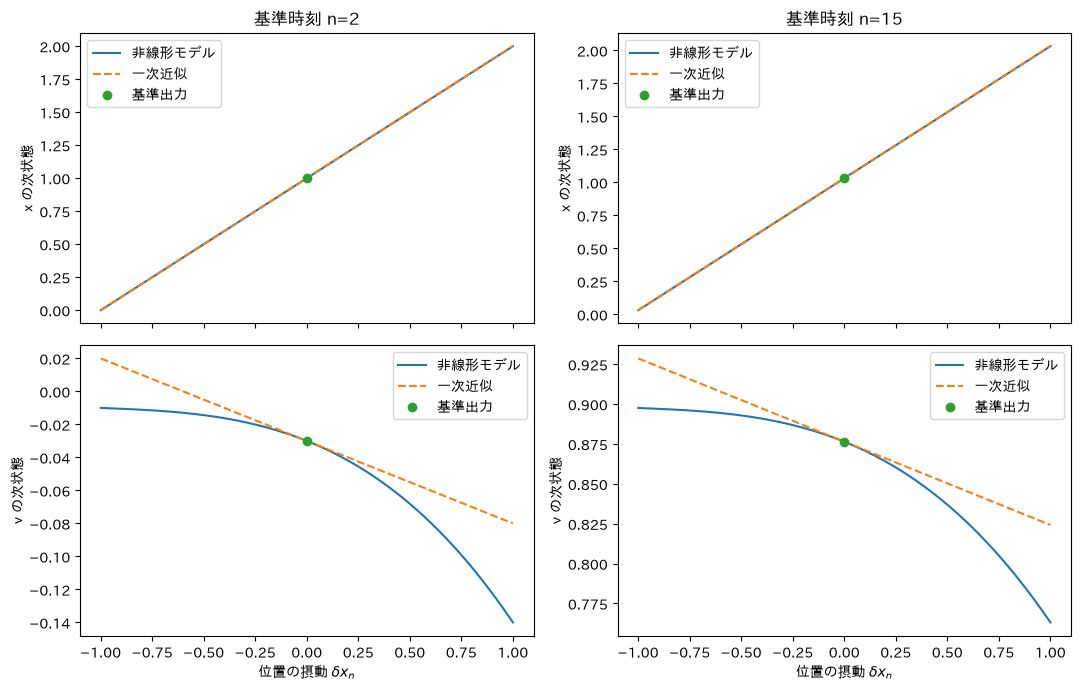

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

dt = 0.01
m = 1.0
k = 0.5
k3 = 1.5

# 非線形バネの状態方程式
def f(x, v, u):
    return np.array([x + dt*v,
                     v + dt/m*(-k*x - k3*x**3 + u)])

# 状態方程式の状態に関するヤコビ行列
def A(x,v,u):
    return np.array([[1 , dt],
                     [-dt/m*(k + 3*k3*x**2), 1]])

# 状態方程式の入力に関するヤコビ行列
def B(x,v,u):
    return np.array([[0],
                     [dt/m]])
    
def main():
    
    # 基準軌道の初期化
    N = 20
    x_0 = 1.0
    v_0 = 0.0
    U = np.array([i for i in range(N)])
    X = np.zeros((N+1, 2))

    # 基準軌道
    X[0, :] = np.array([x_0, v_0])
    for i in range(1, N+1):
        x, v = f(X[i-1, 0], X[i-1, 1], U[i-1])
        X[i, :] = np.array([x, v])
    
    # 基準位置1
    idx1 = 2
    
    # 基準位置2
    idx2 = 15
    
    fig, ax = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

    # xの摂動に対する次状態の変化を確認
    dx_values = np.linspace(-1.0, 1.0, 201)

    for col, idx in enumerate([idx1, idx2]):
        bar_X = X[idx]
        bar_u = U[idx]
        bar_next = f(bar_X[0], bar_X[1], bar_u)
        A_n = A(bar_X[0], bar_X[1], bar_u)

        true_next = np.array([
            f(bar_X[0] + dx, bar_X[1], bar_u)
            for dx in dx_values
        ])

        linear_next = np.array([
            bar_next + A_n @ np.array([dx, 0.0])
            for dx in dx_values
        ])

        for row, name in enumerate(["x", "v"]):
            ax[row, col].plot(
                dx_values, true_next[:, row], label="非線形モデル"
            )
            ax[row, col].plot(
                dx_values, linear_next[:, row], "--", label="一次近似"
            )
            ax[row, col].plot(
                0, bar_next[row], "o", label="基準出力"
            )
            ax[row, col].set_ylabel(f"{name} の次状態")
            ax[row, col].legend()

        ax[0, col].set_title(f"基準時刻 n={idx}")
        ax[1, col].set_xlabel(r"位置の摂動 $\delta x_n$")

    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


基準点を2点おき、そこでの非線形バネとそれを一次近似したモデルの出力を表示している。摂動は$\delta x_n$のみとし、この時の状態$X_n$の違いを示している。

図の1行目が位置$x$、2行目が速度$v$の非線形モデルと一次近似モデルの差を示している。図が示すように、速度$v$にのみ差が生じている。

摂動は $x_{n} + \delta x_n$のみ行っているので、これを非線形バネの状態方程式に適用すると次のようになる。($\bar{x}_n, \bar{v}_n, \bar{u}_n$)は基準点であり、そこから $\delta x_n$ を摂動させているため、$x_{n+1}$は線形となり、$v_{n+1}$は非線形となっていることが分かる。

$$
\begin{aligned}
X_{n+1} =
\begin{bmatrix} 
x_{n+1} \\
v_{n+1} 
\end{bmatrix} &=
\begin{bmatrix}
\bar{x}_n + \delta x_n + \Delta t \bar{v}_n \\
\bar{v}_n + \dfrac{\Delta t}{m}\left(\bar{u}_n - k (\bar{x}_n+\delta x_n)- k_3( \bar{x}_n + \delta x_n)^3 \right)
\end{bmatrix} \\
\end{aligned}
$$

次に一次近似モデルの式に適用すると、次のようになる。よって、位置も速度も線形となっていることが分かる。

$$
\begin{aligned}
X_{n+1}^{lin}  = 
\begin{bmatrix} 
x_{n+1}^{lin} \\
v_{n+1}^{lin} 
\end{bmatrix} &=
\bar{X}_{n+1} + 
\begin{bmatrix}
1 & \Delta t \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) & 1
\end{bmatrix}
\begin{bmatrix} \delta x_n \\ 0 \end{bmatrix}
+\begin{bmatrix}
0 \\
\dfrac{\Delta t}{m}
\end{bmatrix} 0 \\
&=
\begin{bmatrix} 
\bar{x}_n + \Delta t \bar{v}_n \\
\bar{v}_{n} + \dfrac{\Delta t}{m}\left(\bar{u}_n + k \bar{x}_n + k_3 \bar{x}_n^3 \right) 
\end{bmatrix} +
\begin{bmatrix}
\delta x_n \\
- \dfrac{\Delta t}{m}\left( k + 3 k_3 \bar{x}_n^2 \right) \delta x_n
\end{bmatrix}
\end{aligned}
$$  

以上より、非線形バネでは、速度のみが非線形と線形の差が生じることが分かる。また、$\delta v_{n}, \delta u_{n}$を摂動させても、もともとの$v_n,u_n$が非線形ではないため変化がないといえる。
